Epoch 0, Loss: 41.144238
Epoch 500, Loss: 10.565679
Epoch 1000, Loss: 10.461695
Epoch 1500, Loss: 10.309250
Epoch 2000, Loss: 10.202821
Epoch 2500, Loss: 10.092242
Epoch 3000, Loss: 10.039145
Epoch 3500, Loss: 9.997484
Epoch 4000, Loss: 9.953786
Epoch 4500, Loss: 9.917978


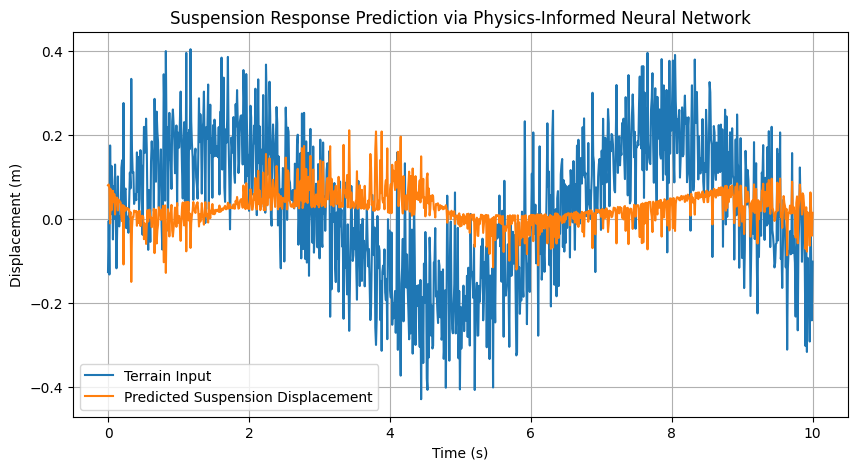

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

def generate_terrain(length=1000, resolution=0.1):
    x = np.arange(0, length, resolution)
    terrain = 0.2 * np.sin(0.1 * x) + 0.1 * np.random.randn(len(x))
    return x, terrain

class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, t, terrain):
        input = torch.cat([t.unsqueeze(1), terrain.unsqueeze(1)], dim=1)
        return self.net(input)

def physics_loss(model, t, terrain, mass=1.0, k=20.0, c=5.0):
    t.requires_grad_(True)
    terrain.requires_grad_(True)

    x = model(t, terrain)
    dx = torch.autograd.grad(x, t, torch.ones_like(x), create_graph=True)[0]
    ddx = torch.autograd.grad(dx, t, torch.ones_like(dx), create_graph=True)[0]

    force_spring = -k * (x - terrain)
    force_damper = -c * dx
    total_force = force_spring + force_damper
    loss = torch.mean((mass * ddx - total_force) ** 2)
    return loss

def main():
    x_np, terrain_np = generate_terrain()
    terrain_np = terrain_np[:1000]

    terrain = torch.tensor(terrain_np, dtype=torch.float32)
    t = torch.linspace(0, 10, len(terrain))

    model = PINN()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    epochs = 5000
    for epoch in range(epochs):
        optimizer.zero_grad()
        loss = physics_loss(model, t, terrain)
        loss.backward()
        optimizer.step()

        if epoch % 500 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

    model.eval()
    with torch.no_grad():
        x_pred = model(t, terrain).squeeze().numpy()

    plt.figure(figsize=(10, 5))
    plt.plot(t.detach().numpy(), terrain_np, label="Terrain Input")
    plt.plot(t.detach().numpy(), x_pred, label="Predicted Suspension Displacement")
    plt.legend()
    plt.title("Suspension Response Prediction via Physics-Informed Neural Network")
    plt.xlabel("Time (s)")
    plt.ylabel("Displacement (m)")
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()
